In [1]:
import cloudViewer as cv3d
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import sys

# only needed for tutorial, monkey patches visualization
sys.path.append('..')
import cloudViewer_tutorial as cv3dtut
# change to True if you want to interact with the visualization windows
cv3dtut.interactive = not "CI" in os.environ

Using external CloudViewer-ML in /root/CloudViewer-ML


# Transformation
The geometry types of CloudViewer have a number of transformation methods. In this tutorial we show how to use `translate`, `rotate`, `scale`, and `transform`.

## Translate
The first transformation method we want to look at is `translate`. The translate method takes a single 3D vector $t$ as input and translates all points/vertices of the geometry by this vector, $v_t = v + t$. The code below shows how the mesh is translated once in the x-directon and once in the y-direction.

Center of mesh: [0.05167549 0.05167549 0.05167549]
Center of mesh tx: [1.35167544 0.05167549 0.05167549]
Center of mesh ty: [0.05167549 1.35167544 0.05167549]
[CloudViewer WARNING] GLFW Error: X11: The DISPLAY environment variable is missing
[CloudViewer WARNING] GLFW initialized for headless rendering.


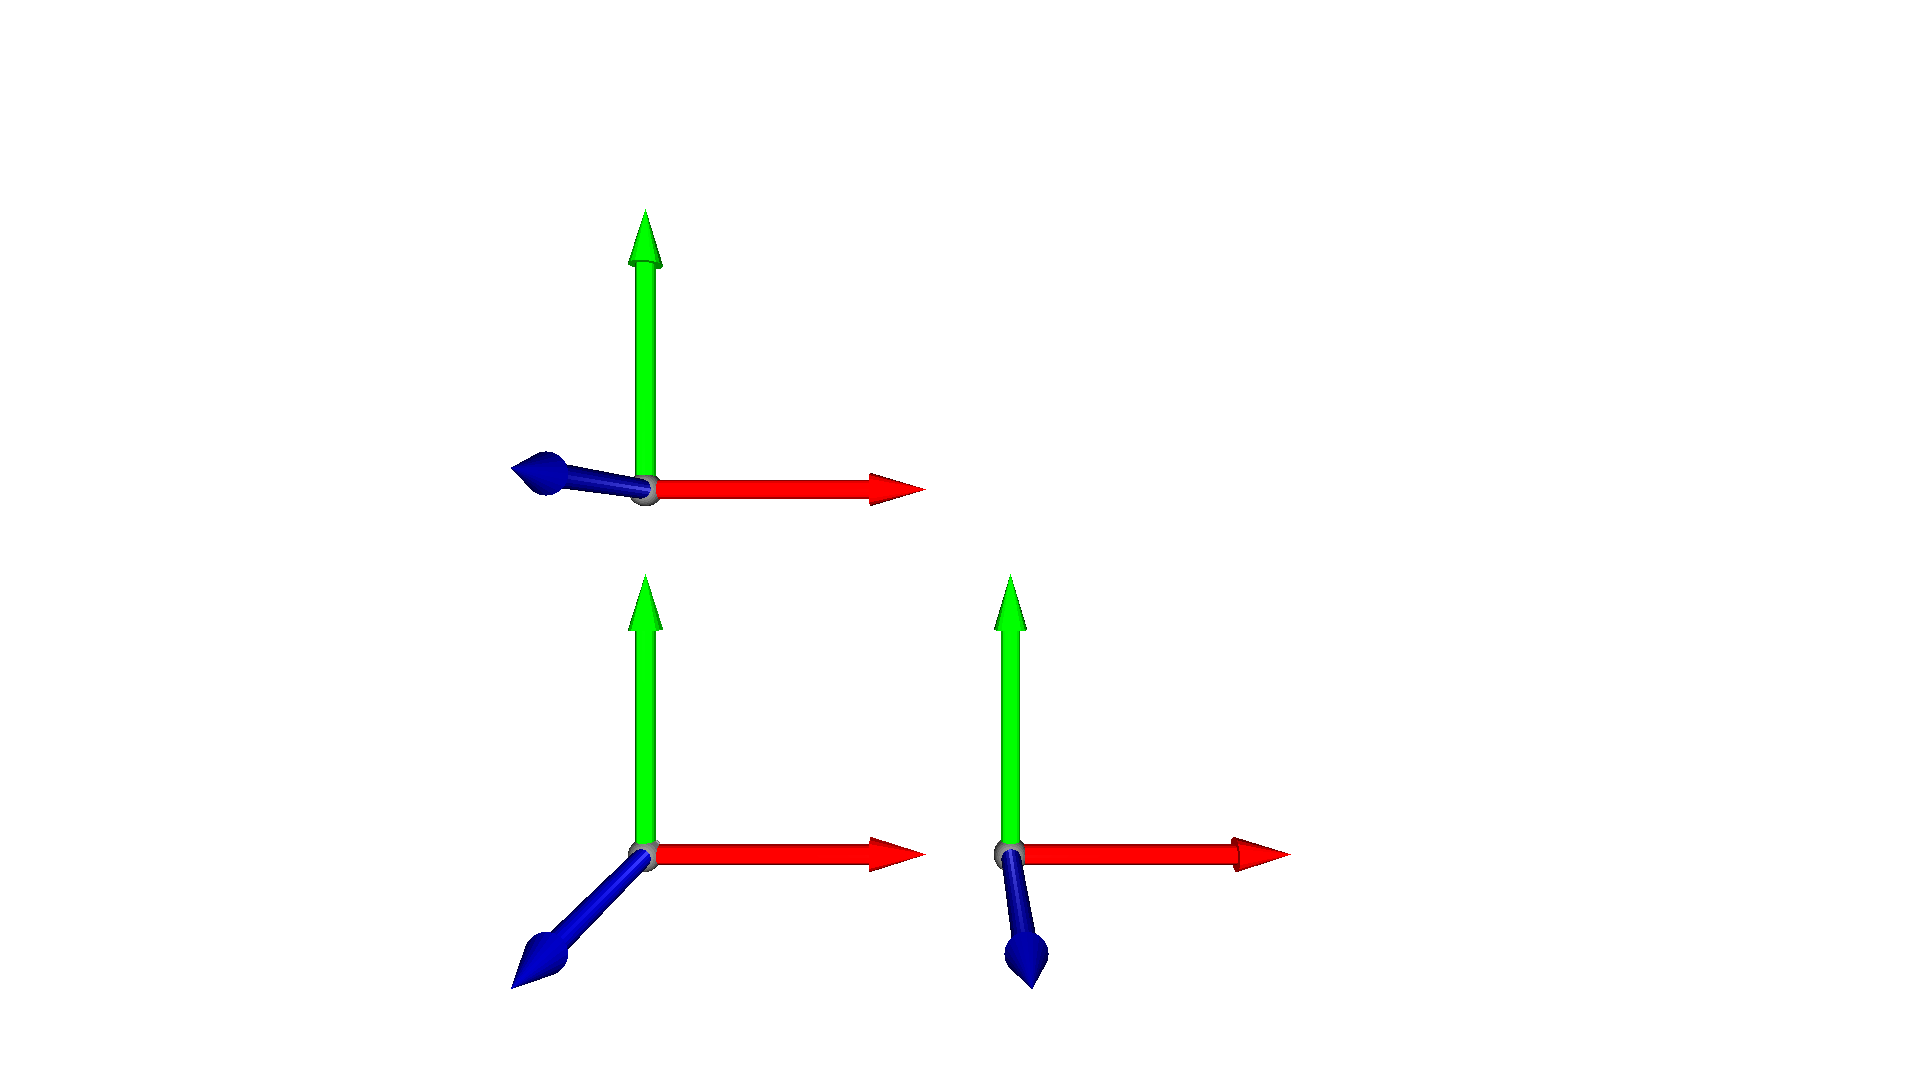

In [2]:
mesh = cv3d.geometry.ccMesh.create_coordinate_frame()
mesh_tx = copy.deepcopy(mesh).translate((1.3, 0, 0))
mesh_ty = copy.deepcopy(mesh).translate((0, 1.3, 0))
print(f'Center of mesh: {mesh.get_center()}')
print(f'Center of mesh tx: {mesh_tx.get_center()}')
print(f'Center of mesh ty: {mesh_ty.get_center()}')
cv3d.visualization.draw_geometries([mesh, mesh_tx, mesh_ty])

<div class="alert alert-info">
    
**Note:** 

The method `get_center` returns the mean of the `TriangleMesh` vertices. That means that for a coordinate frame created at the origin `[0,0,0]`, `get_center` will return `[0.05167549 0.05167549 0.05167549]`.

</div>

The method takes a second argument `relative` that is by default set to `True`. If set to `False`, the center of the geometry is translated directly to the position specified in the first argument.

Center of mesh: [0.05167549 0.05167549 0.05167549]
Center of translated mesh: [2.00000005 2.00000005 2.00000005]
[CloudViewer WARNING] GLFW initialized for headless rendering.


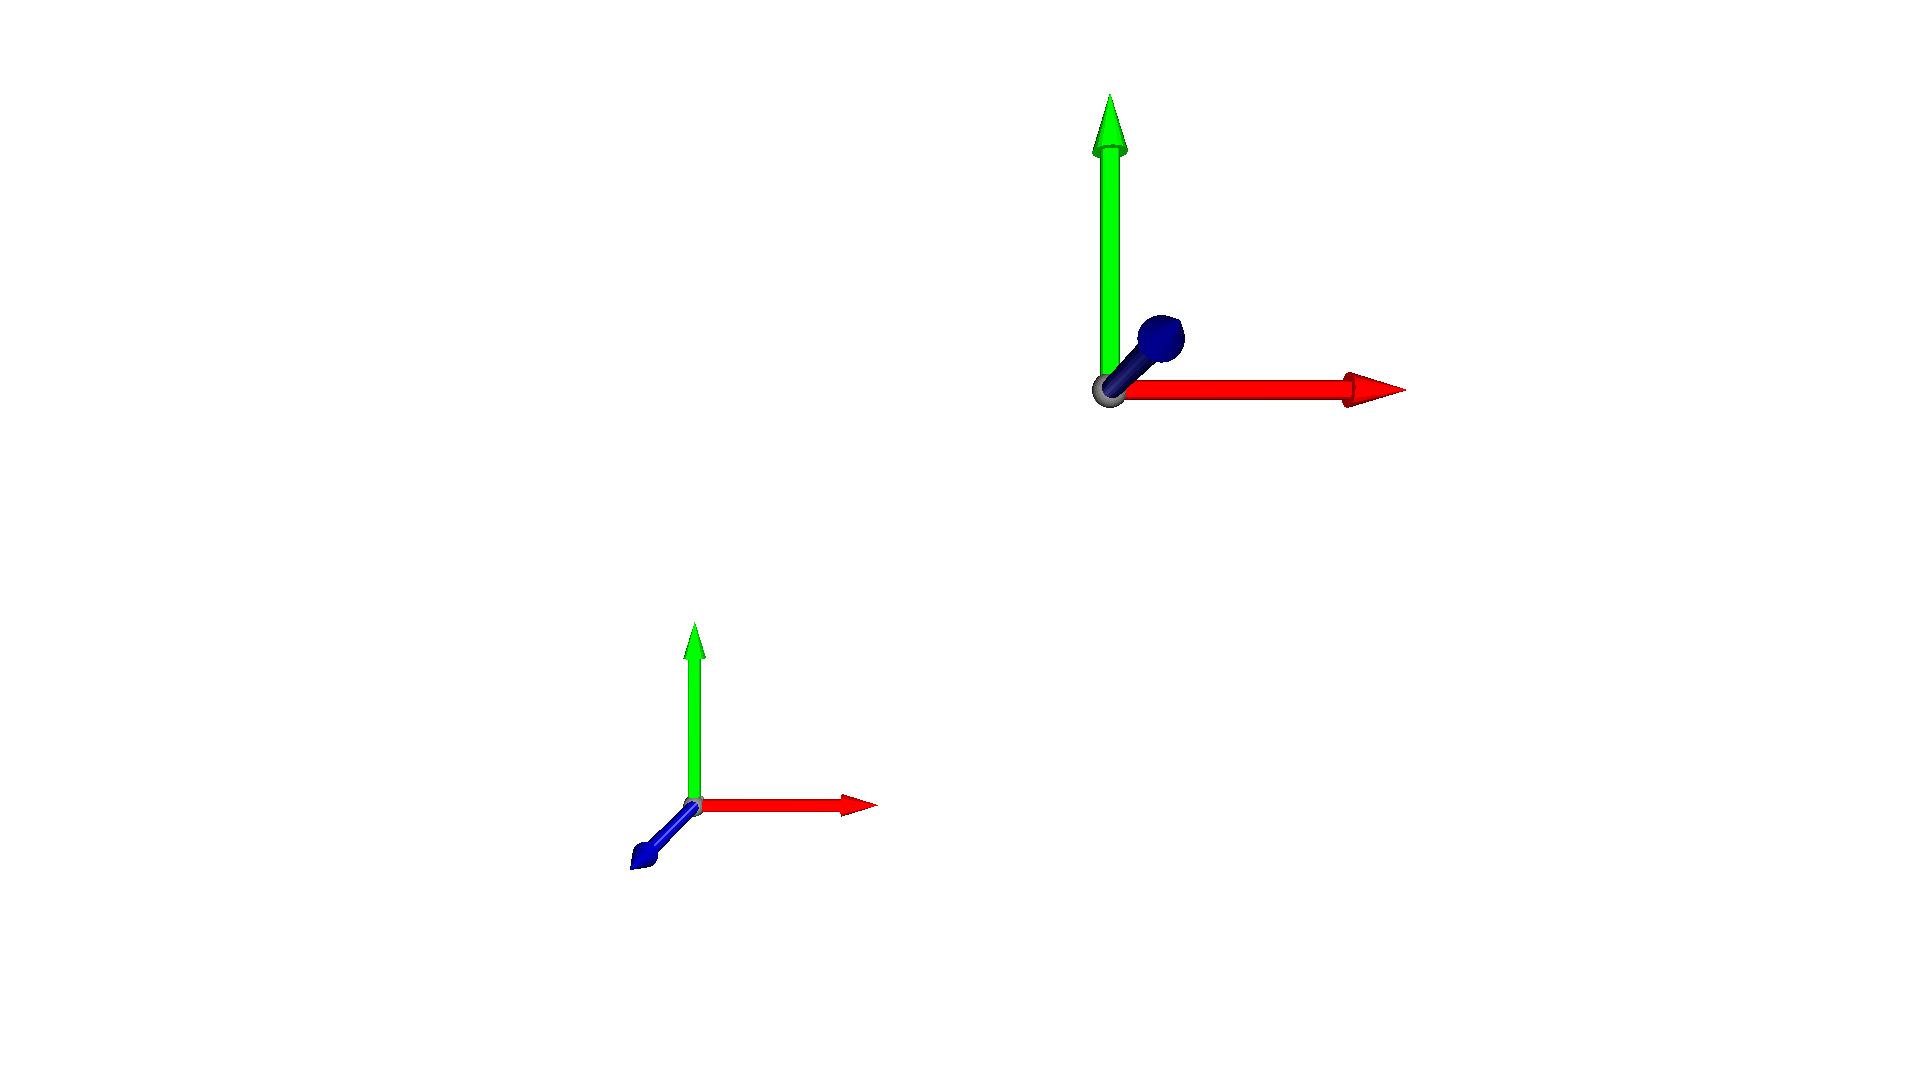

In [3]:
mesh = cv3d.geometry.ccMesh.create_coordinate_frame()
mesh_mv = copy.deepcopy(mesh).translate((2, 2, 2), relative=False)
print(f'Center of mesh: {mesh.get_center()}')
print(f'Center of translated mesh: {mesh_mv.get_center()}')
cv3d.visualization.draw_geometries([mesh, mesh_mv])

## Rotation
The geometry types of CloudViewer can also be rotated with the method `rotate`. It takes as first argument a rotation matrix `R`. As rotations in 3D can be parametrized in a number of ways, CloudViewer provides convenience functions to convert from different parametrizations to rotation matrices:

- Convert from [Euler angles](https://en.wikipedia.org/wiki/Euler_angles) with `get_rotation_matrix_from_xyz` (where `xyz` can also be of the form `yzx`, `zxy`, `xzy`, `zyx`, and `yxz`)
- Convert from [Axis-angle representation](https://en.wikipedia.org/wiki/Axis%E2%80%93angle_representation) with `get_rotation_matrix_from_axis_angle`
- Convert from [Quaternions](https://en.wikipedia.org/wiki/Quaternion) with `get_rotation_matrix_from_quaternion`

In the code below we rotate the mesh using Euler angles.

[CloudViewer WARNING] GLFW initialized for headless rendering.


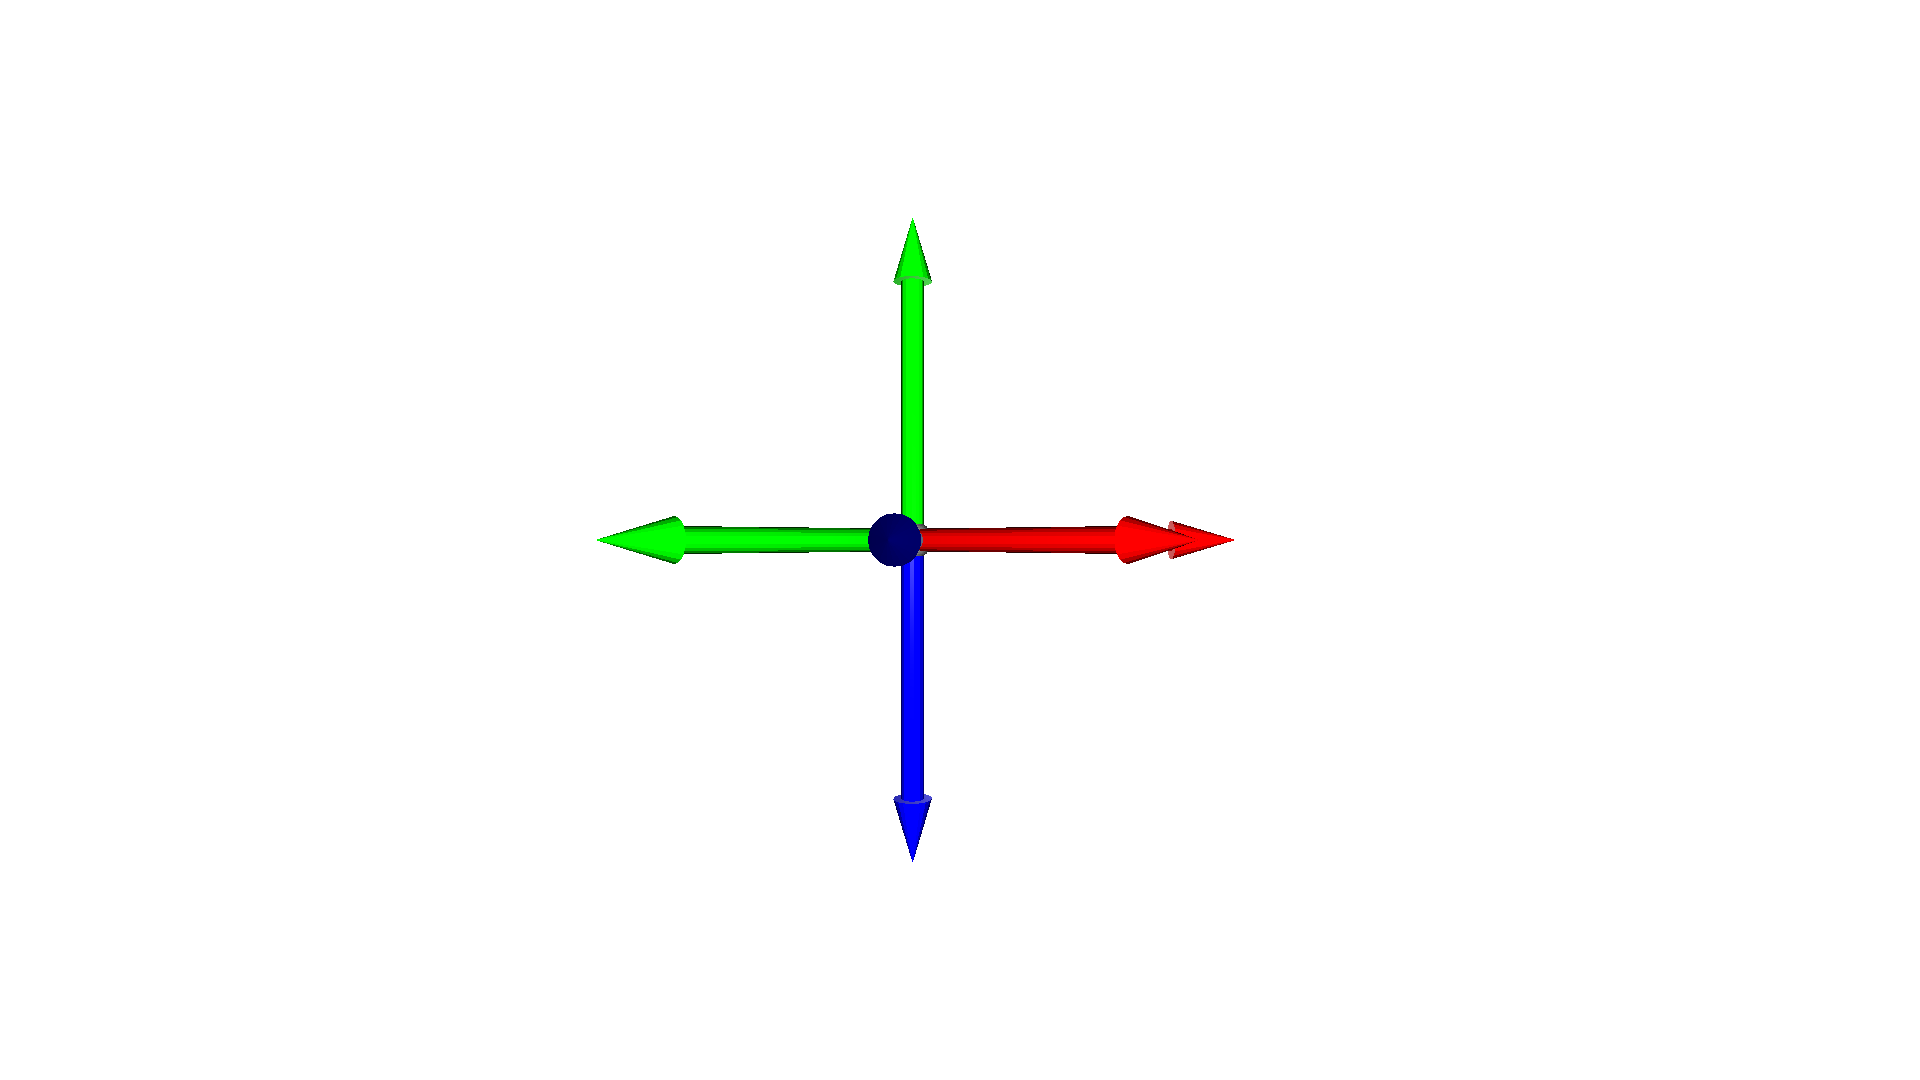

In [4]:
mesh = cv3d.geometry.ccMesh.create_coordinate_frame()
mesh_r = copy.deepcopy(mesh)
R = mesh.get_rotation_matrix_from_xyz((np.pi / 2, 0, np.pi / 4))
mesh_r.rotate(R, center=(0, 0, 0))
cv3d.visualization.draw_geometries([mesh, mesh_r])

The function `rotate` has a second argument `center` that is by default set to `True`. This indicates that the object is first centered prior to applying the rotation and then moved back to its previous center. If this argument is set to `False`, then the rotation will be applied directly, such that the whole geometry is rotated around the coordinate center. This implies that the mesh center can be changed after the rotation.

[CloudViewer WARNING] GLFW initialized for headless rendering.


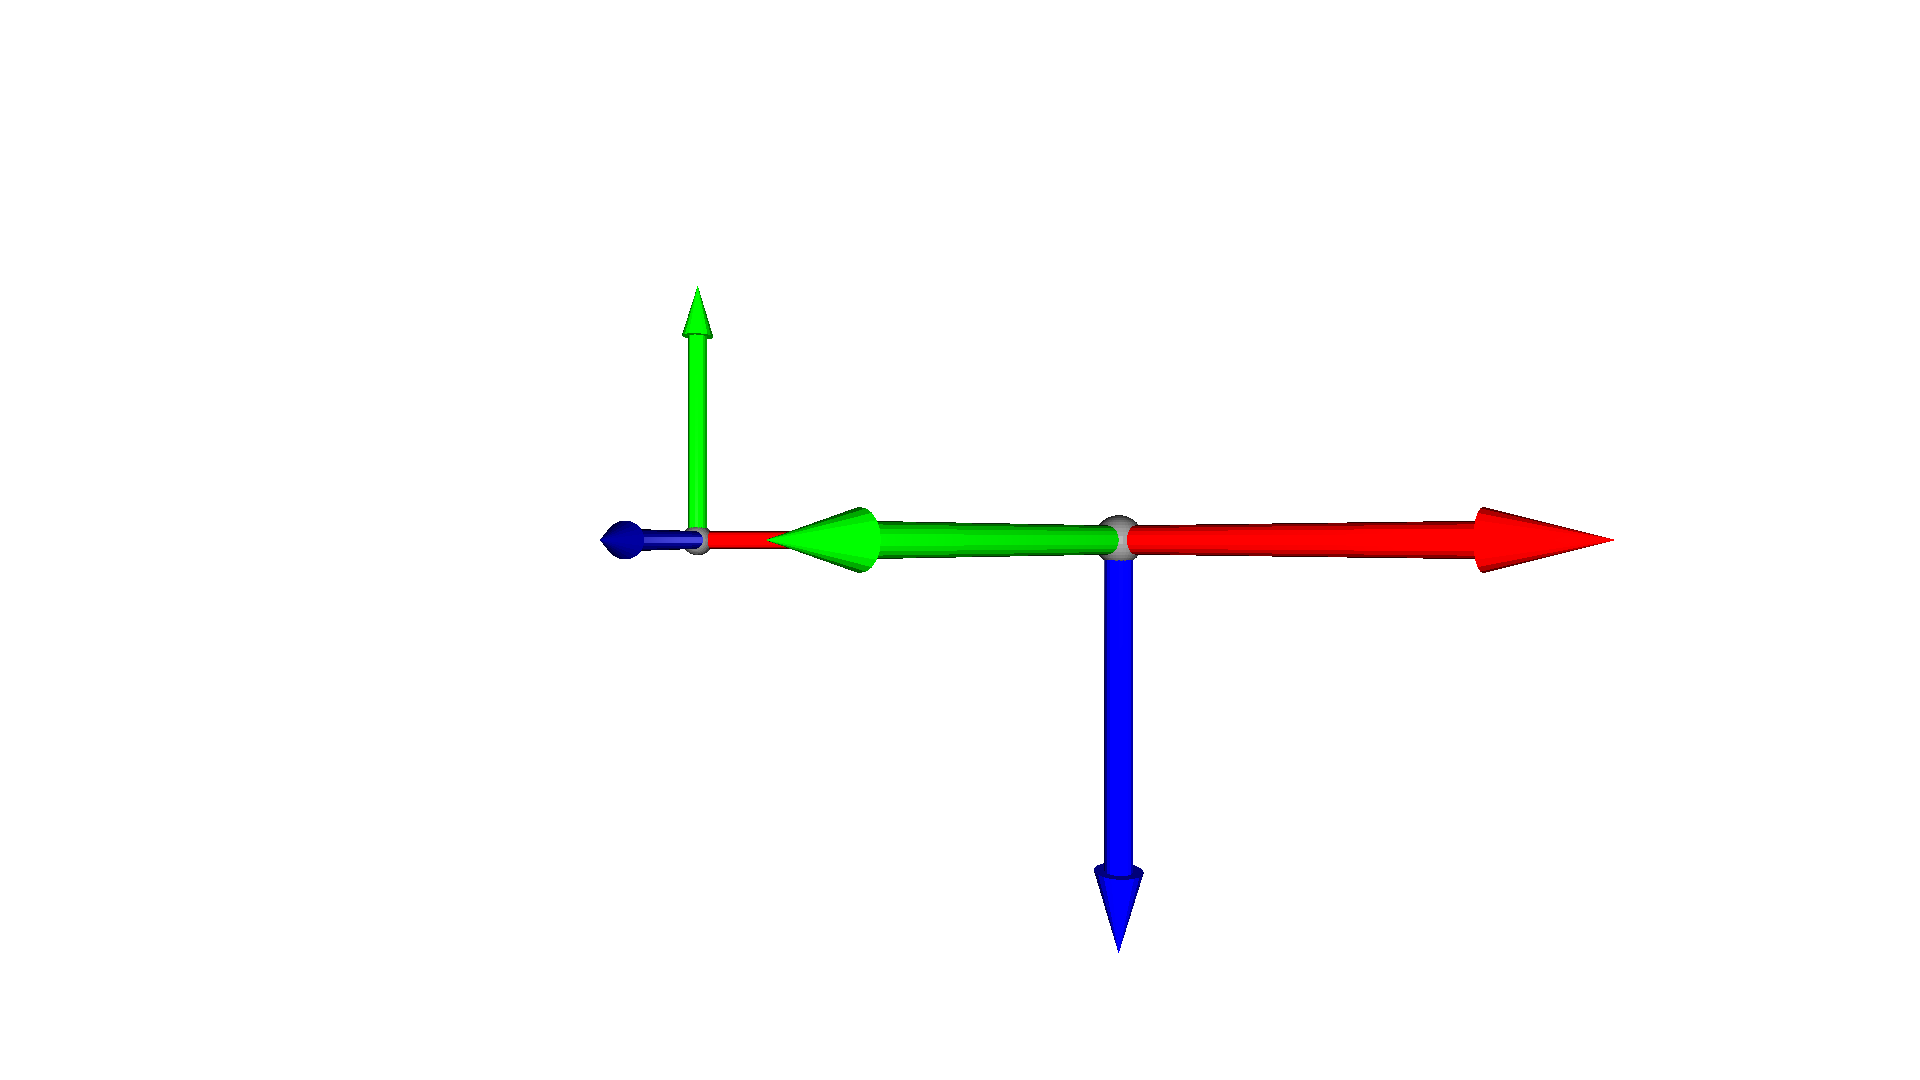

In [5]:
mesh = cv3d.geometry.ccMesh.create_coordinate_frame()
mesh_r = copy.deepcopy(mesh).translate((2, 0, 0))
mesh_r.rotate(mesh.get_rotation_matrix_from_xyz((np.pi / 2, 0, np.pi / 4)),
              center=(0, 0, 0))
cv3d.visualization.draw_geometries([mesh, mesh_r])

## Scale
Vertices and points of CloudViewer geometry types can also be scaled using `scale`, $v_s = s \cdot v$. 

[CloudViewer WARNING] GLFW initialized for headless rendering.


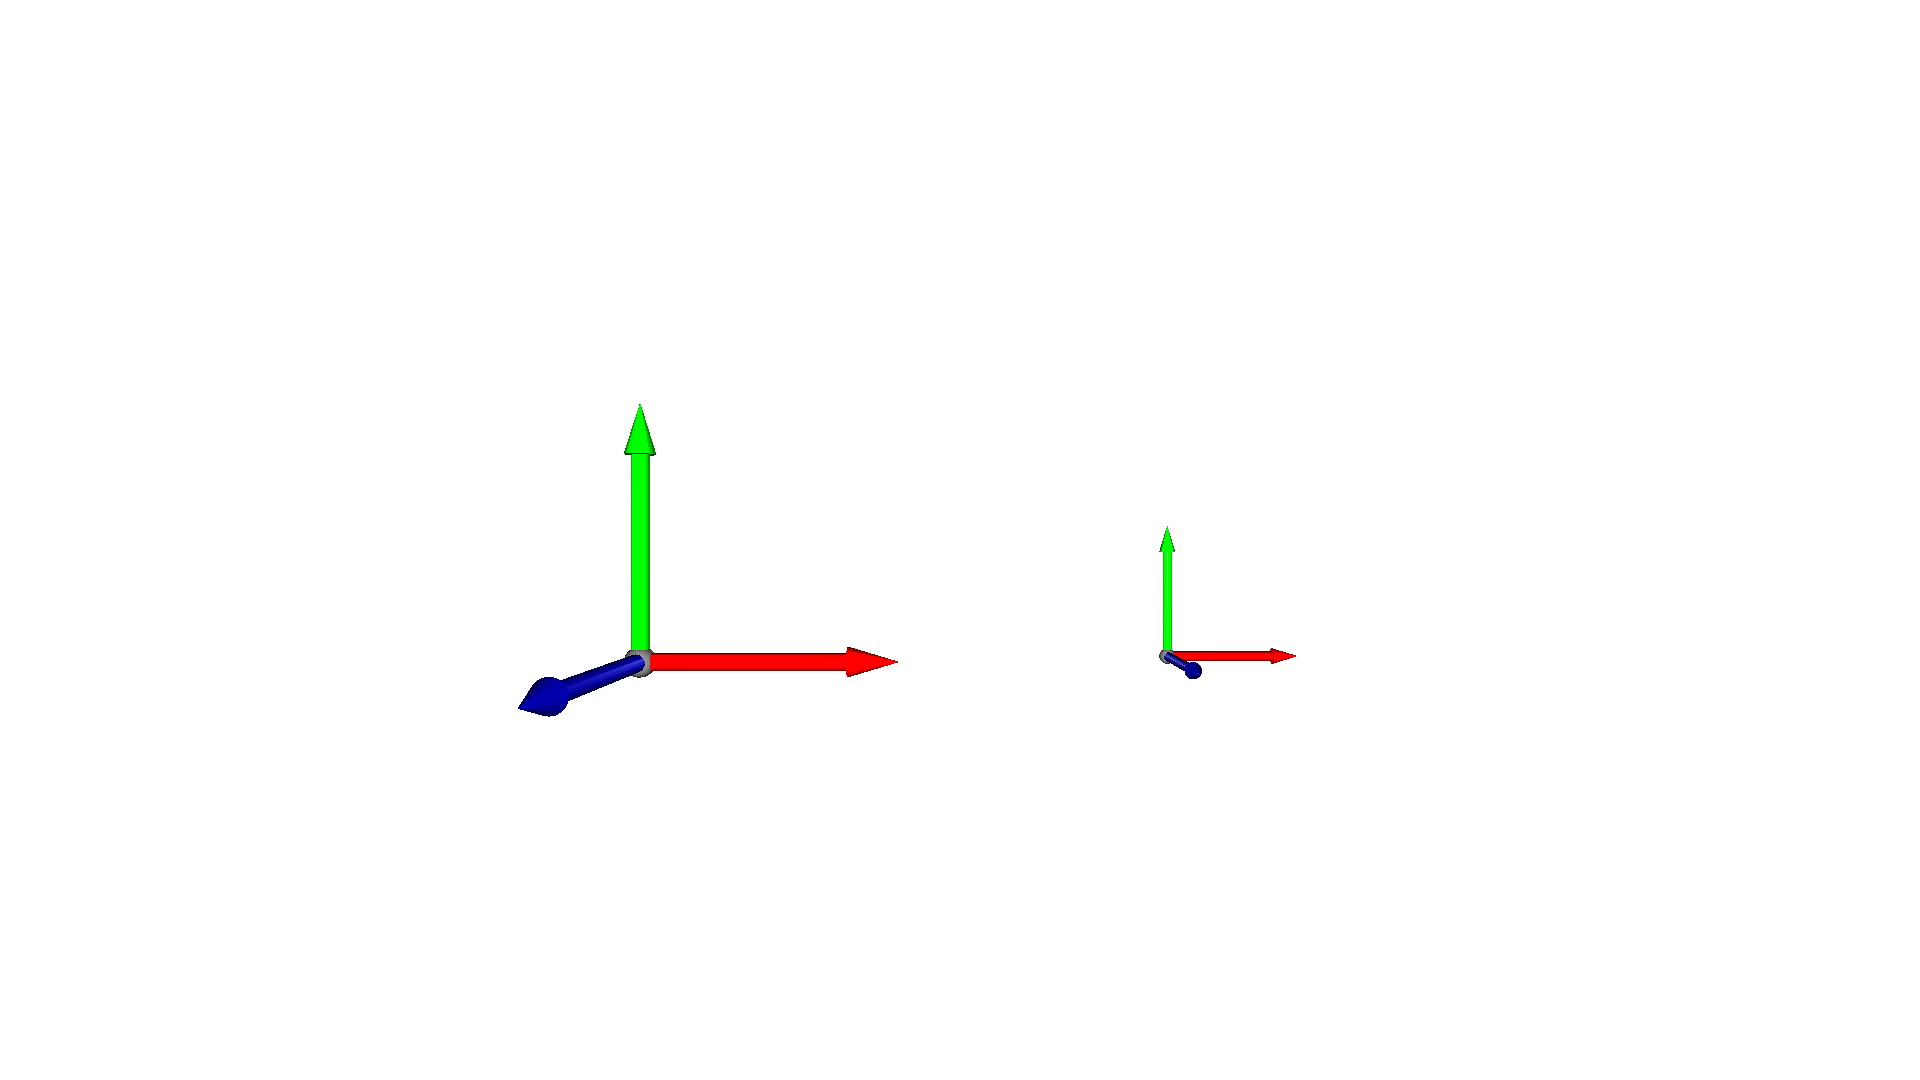

In [6]:
mesh = cv3d.geometry.ccMesh.create_coordinate_frame()
mesh_s = copy.deepcopy(mesh).translate((2, 0, 0))
mesh_s.scale(0.5, center=mesh_s.get_center())
cv3d.visualization.draw_geometries([mesh, mesh_s])

The `scale` method also has a second argument `center` that is set to `True` by default. If it is set to `False`, then the object is not centered prior to scaling such that the center of the object can move due to the scaling operation.

[CloudViewer WARNING] GLFW initialized for headless rendering.


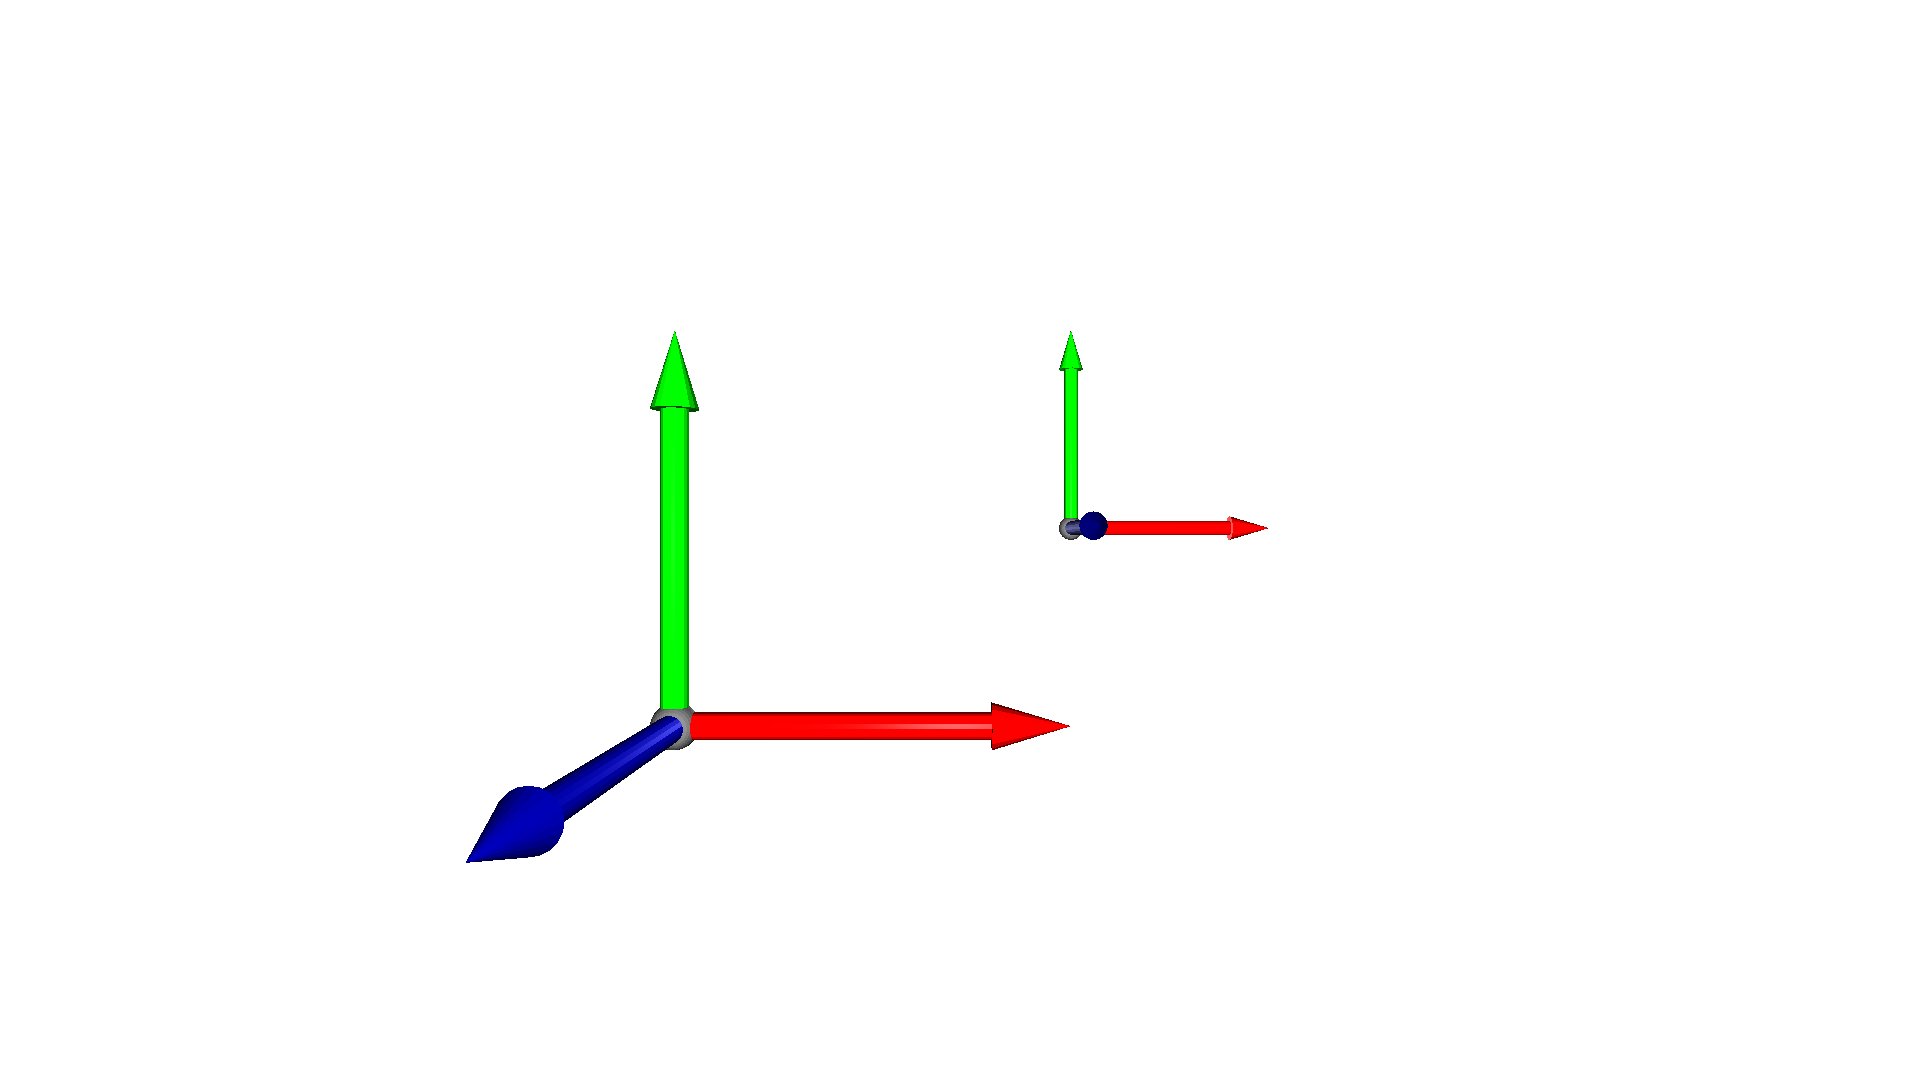

In [7]:
mesh = cv3d.geometry.ccMesh.create_coordinate_frame()
mesh_s = copy.deepcopy(mesh).translate((2, 1, 0))
mesh_s.scale(0.5, center=(0, 0, 0))
cv3d.visualization.draw_geometries([mesh, mesh_s])

## General transformation
CloudViewer also supports a general transformation defined by a $4\times4$ homogeneous transformation matrix using the method `transform`.

[[ 3.06161700e-17 -5.00000000e-01  8.66025404e-01  1.00000000e+00]
 [ 1.00000000e+00  6.12323400e-17  0.00000000e+00  1.30000000e+00]
 [-5.30287619e-17  8.66025404e-01  5.00000000e-01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[CloudViewer WARNING] GLFW initialized for headless rendering.


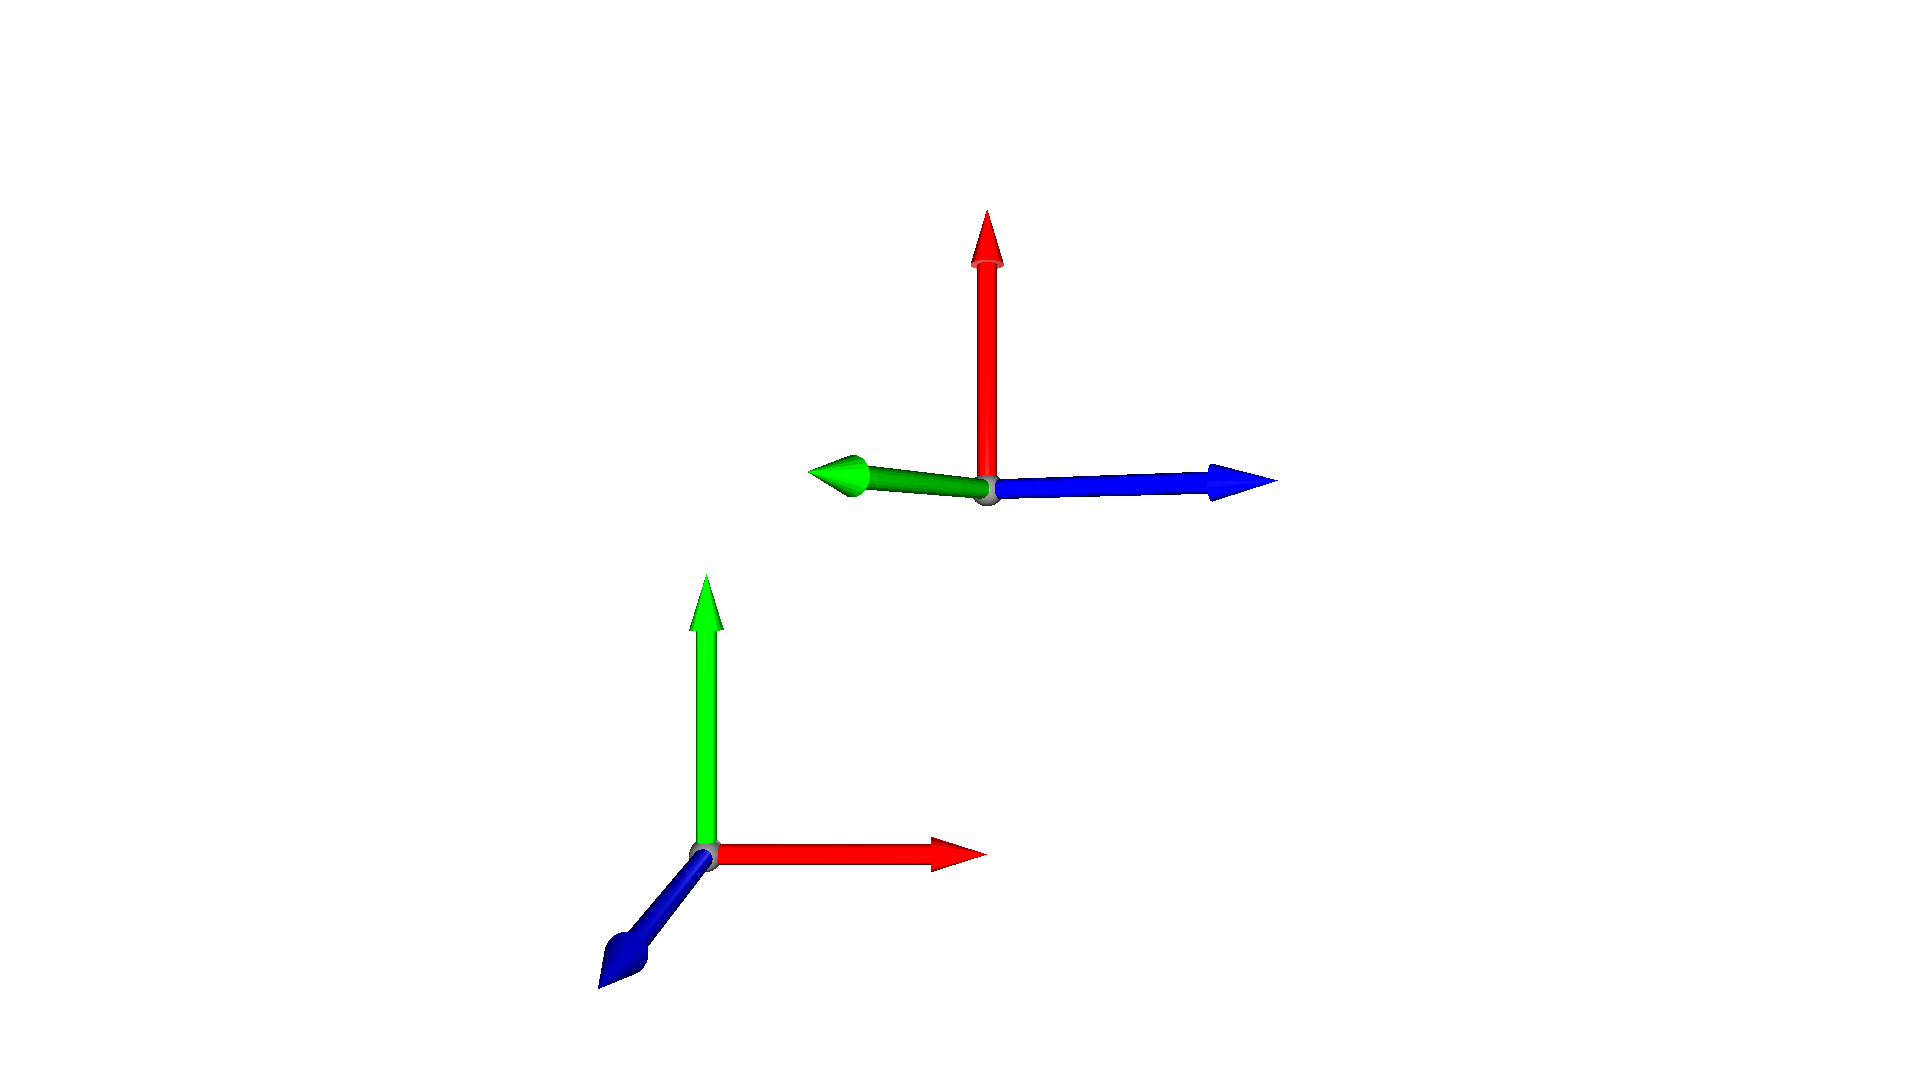

In [8]:
mesh = cv3d.geometry.ccMesh.create_coordinate_frame()
T = np.eye(4)
T[:3, :3] = mesh.get_rotation_matrix_from_xyz((0, np.pi / 3, np.pi / 2))
T[0, 3] = 1
T[1, 3] = 1.3
print(T)
mesh_t = copy.deepcopy(mesh).transform(T)
cv3d.visualization.draw_geometries([mesh, mesh_t])